In [2]:
import pandas as pd


In [3]:
df=pd.read_csv('rigel_customer_interviews_realistic_1248.csv')

In [4]:
hierarchy = df.groupby(['customer_type', 'organization_type'])['role_title'].unique().reset_index()


for c_type in hierarchy['customer_type'].unique():
    print(f"\n📂 Customer Type: {c_type}")
    orgs = hierarchy[hierarchy['customer_type'] == c_type]

    for _, row in orgs.iterrows():
        roles = ", ".join(row['role_title'])
        print(f"   ├── Organization: {row['organization_type']}")
        print(f"   │   └── Roles: {roles}")




📂 Customer Type: Advisor
   ├── Organization: CIRO dealer
   │   └── Roles: Estate-Focused Advisor, Independent Advisor Team Lead, Wealth Advisor, Senior Financial Planner, Branch Planning Lead
   ├── Organization: Independent dealer team
   │   └── Roles: Wealth Advisor, Senior Financial Planner, Estate-Focused Advisor, Independent Advisor Team Lead, Branch Planning Lead
   ├── Organization: Integrated dealer platform
   │   └── Roles: Independent Advisor Team Lead, Wealth Advisor, Branch Planning Lead, Senior Financial Planner, Estate-Focused Advisor

📂 Customer Type: Enterprise
   ├── Organization: Bank trust division
   │   └── Roles: Trust Operations Lead, Workflow Modernization Manager, Compliance and Risk Lead, Estate Settlement Manager, Fiduciary Services Director
   ├── Organization: Institutional estate operations team
   │   └── Roles: Workflow Modernization Manager, Estate Settlement Manager, Trust Operations Lead, Compliance and Risk Lead, Fiduciary Services Director
   ├

In [3]:
import plotly.express as px

# 剔除缺失值后画图
fig = px.sunburst(df, path=['customer_type', 'organization_type', 'role_title'],
                  values='adoption_score_100', # 颜色深浅可以用评分表示
                  title="Customer Hierarchy Map",
                  template='plotly_white')
fig.show()


In [5]:
print(df.groupby('customer_type')['adoption_score_100'].mean())
pviot_adoption = df.pivot_table(
    index = 'customer_type',
    values = 'adoption_score_100',
    aggfunc = 'mean'
).reset_index()
pviot_adoption

customer_type
Advisor                         74.206604
Enterprise                      64.037818
Estate Planner                  69.777000
Indigenous Governance Office    74.085542
Name: adoption_score_100, dtype: float64


,customer_type,adoption_score_100
0,Advisor,74.206604
1,Enterprise,64.037818
2,Estate Planner,69.777000
3,Indigenous Governance Office,74.085542


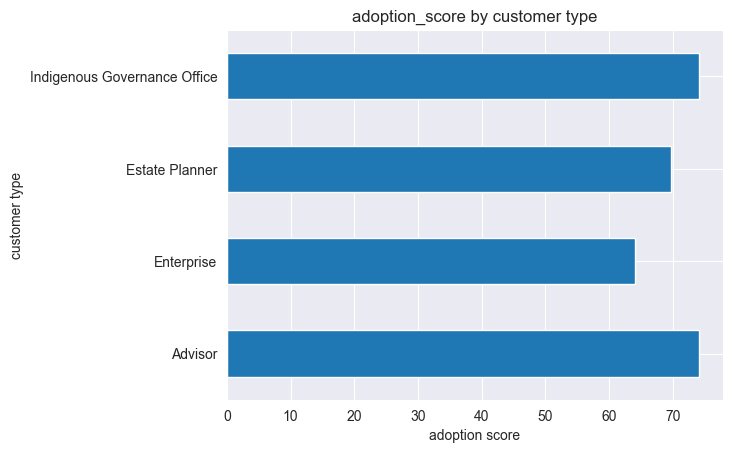

In [10]:
from matplotlib import pyplot as plt

pviot_adoption.plot(
    kind = 'barh',
    x = 'customer_type',
    y = 'adoption_score_100',
    legend = False
)
plt.title('adoption_score by customer type')
plt.xlabel('adoption score')
plt.ylabel('customer type')
plt.show()


In [5]:
# 统计每一层有多少个唯一值c
print(f" (Organization Type) : {df['organization_type'].nunique()}")
print(f" (Role Title) : {df['role_title'].nunique()}")


 (Organization Type) : 14
 (Role Title) : 20


In [19]:
df["decision_role"].value_counts()

decision_role
Decision-maker    467
Influencer        429
Evaluator         252
End user          100
Name: count, dtype: int64

In [25]:
import plotly.graph_objects as go
import pandas as pd

user_channel = df.groupby(['customer_type','decision_role'])[['interview_channel','source_channel']].value_counts()

df_sankey = user_channel.reset_index(name='value')

# Customer Type -> Decision Role -> Interview Channel -> Source Channel)
links = []
layers = ['customer_type', 'decision_role', 'interview_channel', 'source_channel']

for i in range(len(layers)-1):
    temp = df_sankey.groupby([layers[i], layers[i+1]])['value'].sum().reset_index()
    temp.columns = ['source', 'target', 'value']
    links.append(temp)

all_links = pd.concat(links)


nodes = list(pd.unique(all_links[['source', 'target']].values.ravel('K')))
node_dict = {node: i for i, node in enumerate(nodes)}

all_links['target_id'] = all_links['target'].map(node_dict)
all_links['source_id'] = all_links['source'].map(node_dict)


fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = nodes,
      color = "royalblue"
    ),
    link = dict(
      source = all_links['source_id'],
      target = all_links['target_id'],
      value = all_links['value'],
      color = "rgba(173, 216, 230, 0.4)"
  ))])

fig.update_layout(title_text="Customer Channel Flow (Sankey Diagram)", font_size=12)
fig.show()


In [17]:
df['must_haves_list'] = df['must_haves'].str.strip(';').str.split(';')


df_exploded = df.explode('must_haves_list')

df_exploded['must_haves_list'] = df_exploded['must_haves_list'].str.strip()


result = pd.crosstab(df_exploded['customer_type'], df_exploded['must_haves_list'], normalize='index')
result

must_haves_list,Activity logs and versioned outputs,Beneficiary and distribution clarity with gap flags,Calculation appendix for deeper review,Compliance export packs,Deterministic repeatable engine,Deterministic show-your-work outputs,"Deterministic, auditable logic",Explicit bypass vs through-estate mapping,"Exportable, meeting-ready reporting",First-class Indigenous trust workflows,...,One-click PDF/CSV export,Predictable implementation and supportability,Reliability in live meetings,Role-based access and permissioning,Scenario comparisons that reuse existing data,Single source of truth for estate flow logic,Standardized outputs across teams,Traceability and versioning,Transparent Section 87 handling with explicit logic,Workflows that respect governance and cultural context
customer_type,,,,,,,,,,,,,,,,,,,,,
Advisor,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.170031,0.000000,0.000000,0.00000,...,0.156056,0.000000,0.178571,0.000000,0.165373,0.000000,0.000000,0.000000,0.000000,0.000000
Enterprise,0.154791,0.000000,0.000000,0.163391,0.17199,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.157248,0.000000,0.167076,0.000000,0.000000,0.185504,0.000000,0.000000,0.000000
Estate Planner,0.000000,0.204698,0.211409,0.000000,0.00000,0.000000,0.000000,0.183445,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.202461,0.000000,0.197987,0.000000,0.000000
Indigenous Governance Office,0.000000,0.000000,0.000000,0.000000,0.00000,0.211699,0.000000,0.000000,0.200557,0.20195,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.210306,0.175487


In [18]:
result_role = pd.crosstab(df_exploded['decision_role'], df_exploded['must_haves_list'], normalize='index')


print(" (Customer Type)  ===")
print(result.head())

print("\n (Decision Role) ===")
print(result_role.head())


=== 客户类型 (Customer Type) 需求分布 ===
must_haves_list               Activity logs and versioned outputs  \
customer_type                                                       
Advisor                                                  0.000000   
Enterprise                                               0.154791   
Estate Planner                                           0.000000   
Indigenous Governance Office                             0.000000   

must_haves_list               Beneficiary and distribution clarity with gap flags  \
customer_type                                                                       
Advisor                                                                0.000000     
Enterprise                                                             0.000000     
Estate Planner                                                         0.204698     
Indigenous Governance Office                                           0.000000     

must_haves_list               Calculatio

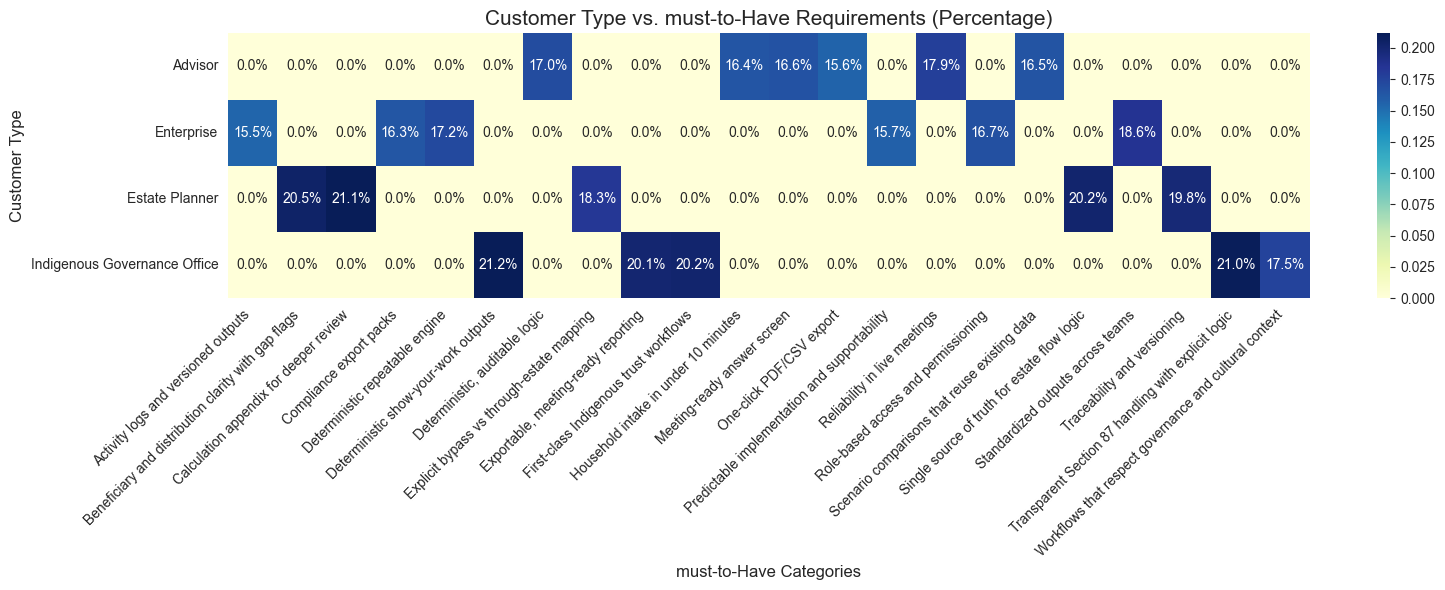

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 6))


sns.heatmap(result, annot=True, cmap='YlGnBu', fmt='.1%')

plt.title('Customer Type vs. must-to-Have Requirements (Percentage)', fontsize=15)
plt.xlabel('must-to-Have Categories', fontsize=12)
plt.ylabel('Customer Type', fontsize=12)


plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()
#0.15-0.20

In [21]:
df_nice_have = df.copy()

df_nice_have['nice_have_list'] = (
    df_nice_have['nice_to_haves']
    .str.strip(';')
    .str.split(';')
)

df_nice_have = df_nice_have.explode('nice_have_list')

df_nice_have['nice_have_list'] = (
    df_nice_have['nice_have_list']
    .str.strip()
)

nicehave = pd.crosstab(
    df_nice_have['customer_type'],
    df_nice_have['nice_have_list'],
    normalize='index'
)

nicehave

nice_have_list,Admin dashboard with usage visibility,Audience-specific export packs,Community-facing summaries,Explainable equity scoring,Flexible workflow configurations by Nation,Light adoption analytics,Lightweight document vault,Optional guided intake prompts,Packaged exports by audience,Plain-language packs for beneficiaries and families,Polished visuals if explainable,Pre-filled templates,Scenario modelling beyond top three client questions,Simple rollout controls,Templates for leadership reporting,Visualisation of competing distribution scenarios
customer_type,,,,,,,,,,,,,,,,
Advisor,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.191424,0.218989,0.000000,0.000000,0.209801,0.171516,0.20827,0.000000,0.00000,0.000000
Enterprise,0.261728,0.00000,0.000000,0.000000,0.000000,0.232099,0.000000,0.000000,0.274074,0.000000,0.000000,0.000000,0.00000,0.232099,0.00000,0.000000
Estate Planner,0.000000,0.31441,0.000000,0.353712,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.331878
Indigenous Governance Office,0.000000,0.00000,0.263708,0.000000,0.266319,0.000000,0.000000,0.000000,0.000000,0.227154,0.000000,0.000000,0.00000,0.000000,0.24282,0.000000


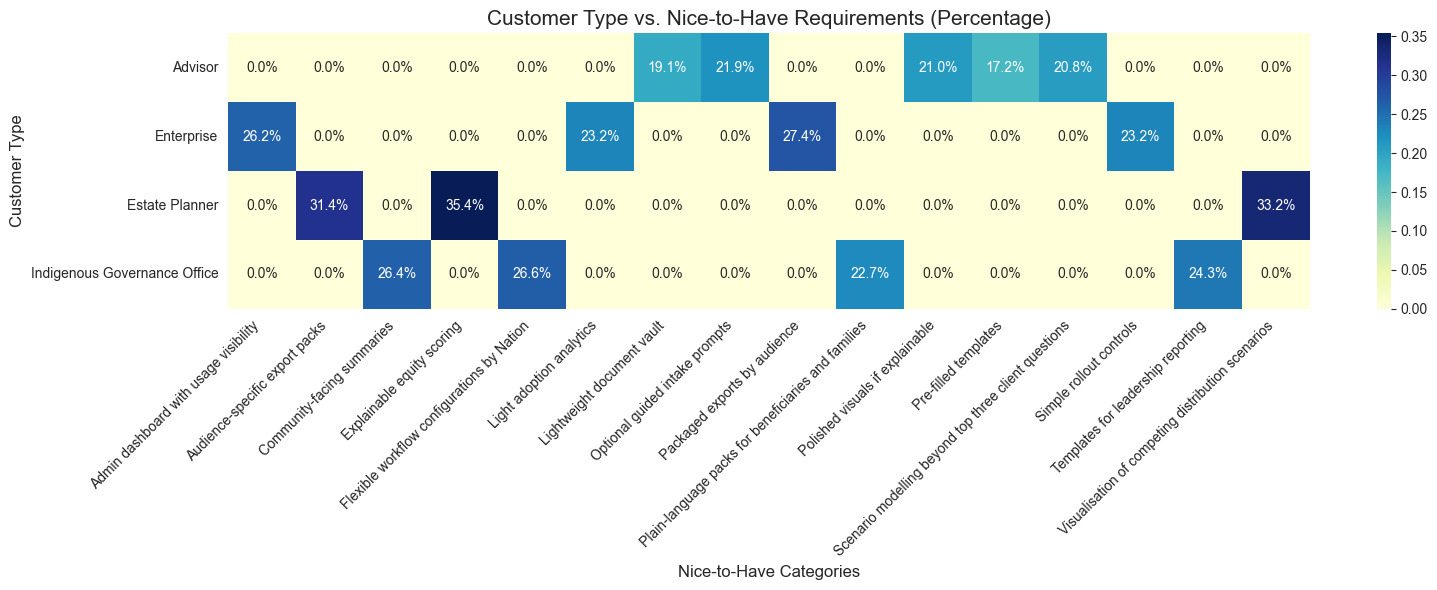

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(16, 6))


sns.heatmap(nicehave, annot=True, cmap='YlGnBu', fmt='.1%')

plt.title('Customer Type vs. Nice-to-Have Requirements (Percentage)', fontsize=15)
plt.xlabel('Nice-to-Have Categories', fontsize=12)
plt.ylabel('Customer Type', fontsize=12)


plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [9]:
df_main_pain = df.copy()
df_main_pain['main_pain_list']= df['primary_pain_point'].str.strip('; ').str.split(';')
df_main_pain = df_main_pain.explode('main_pain_list')

df_main_pain['main_pain_list'] = df_main_pain['main_pain_list'].str.strip()

mainpoint = pd.crosstab(df_main_pain['customer_type'], df_main_pain['main_pain_list'], normalize='index')
mainpoint




main_pain_list,Activity logs and access changes are hard to reconstruct,Analysts rebuild the same maps repeatedly,"Beneficiary details are messy, incomplete, or scattered",Bypass vs through-estate confusion creates advisor risk,Capacity constraints force repetitive manual work,Complex ownership structures are hard to trace,Current systems rely too heavily on informal workarounds,Current tools feel like a CRM instead of a decision tool,Designations are messy or unknown,Distribution outcomes remain unclear until late in the file,...,Manual estate reviews are slow and inconsistent,Manual work leads to audit findings or near-misses,Need to create defensible paper trail quickly,Need to maintain community control while professionalizing workflow,Outputs are hard to defend during compliance review,Reporting must withstand scrutiny from leadership and community,"Section 87 decisions need to be clear, traceable, and reviewable",Specialist bottlenecks slow case resolution,Straightforward cases still take too long to prepare,Workarounds hide risk in free-text notes
customer_type,,,,,,,,,,,,,,,,,,,,,
Advisor,0.000000,0.00,0.160377,0.174528,0.00000,0.000000,0.000000,0.160377,0.000000,0.000000,...,0.176887,0.000000,0.000000,0.00000,0.167453,0.000000,0.000000,0.000000,0.160377,0.000000
Enterprise,0.167273,0.00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.178182,0.000000,0.00000,0.000000,0.000000,0.000000,0.192727,0.000000,0.000000
Estate Planner,0.000000,0.17,0.000000,0.000000,0.00000,0.163333,0.000000,0.000000,0.146667,0.163333,...,0.000000,0.000000,0.153333,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.203333
Indigenous Governance Office,0.000000,0.00,0.000000,0.000000,0.11245,0.000000,0.164659,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.15261,0.000000,0.228916,0.168675,0.000000,0.000000,0.000000


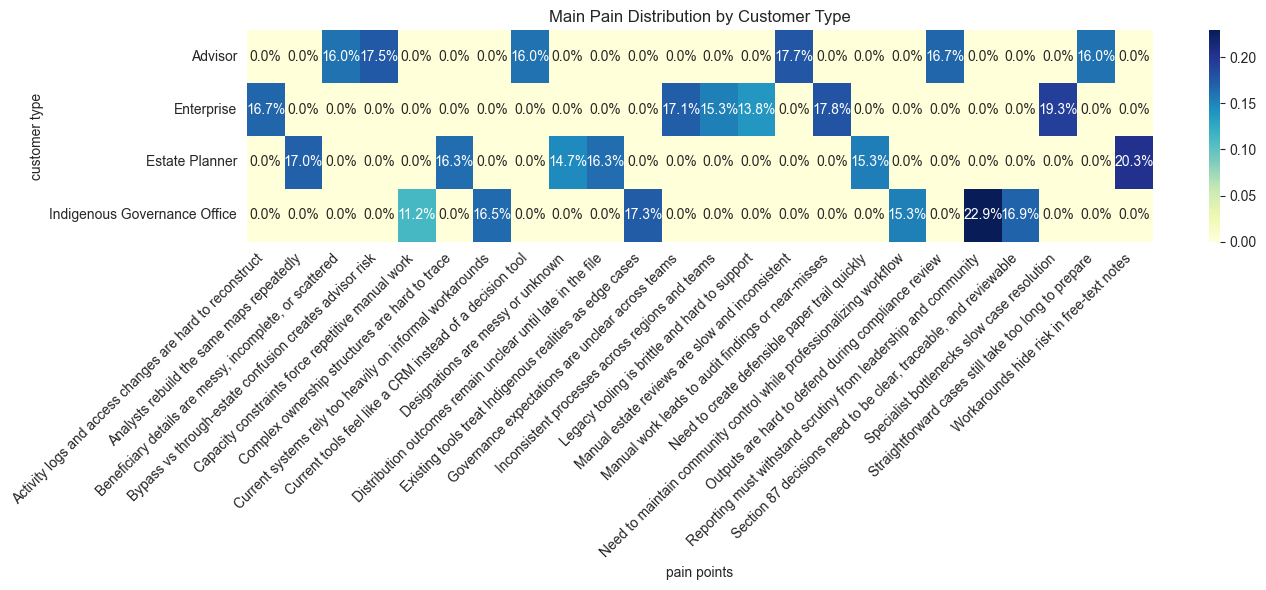

In [10]:
plt.figure(figsize=(14,6))
sns.heatmap(mainpoint, annot=True, cmap='YlGnBu', fmt='.1%')

plt.title('Main Pain Distribution by Customer Type')
plt.xlabel('pain points')
plt.ylabel('customer type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


In [23]:
df_second_pain = df.copy()
df_second_pain['secondary_pain_list'] = df['secondary_pain_points'].str.strip(';').str.split(';')

df_second_pain = df_second_pain.explode('secondary_pain_list')
df_second_pain['secondary_pain_list'] = df_second_pain['secondary_pain_list'].str.strip()
secondpain = pd.crosstab(df_second_pain['customer_type'], df_second_pain['secondary_pain_list'], normalize='index')
secondpain

secondary_pain_list,Activity logs and access changes are hard to reconstruct,Analysts rebuild the same maps repeatedly,"Beneficiary details are messy, incomplete, or scattered",Bypass vs through-estate confusion creates advisor risk,Capacity constraints force repetitive manual work,Complex ownership structures are hard to trace,Current systems rely too heavily on informal workarounds,Current tools feel like a CRM instead of a decision tool,Designations are messy or unknown,Distribution outcomes remain unclear until late in the file,...,Manual estate reviews are slow and inconsistent,Manual work leads to audit findings or near-misses,Need to create defensible paper trail quickly,Need to maintain community control while professionalizing workflow,Outputs are hard to defend during compliance review,Reporting must withstand scrutiny from leadership and community,"Section 87 decisions need to be clear, traceable, and reviewable",Specialist bottlenecks slow case resolution,Straightforward cases still take too long to prepare,Workarounds hide risk in free-text notes
customer_type,,,,,,,,,,,,,,,,,,,,,
Advisor,0.000000,0.000000,0.174118,0.164706,0.000000,0.000000,0.000000,0.184706,0.000000,0.000000,...,0.143529,0.000000,0.000000,0.000000,0.165882,0.000000,0.0000,0.000000,0.167059,0.000000
Enterprise,0.161871,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.152878,0.000000,0.000000,0.000000,0.000000,0.0000,0.176259,0.000000,0.000000
Estate Planner,0.000000,0.167539,0.000000,0.000000,0.000000,0.162304,0.000000,0.000000,0.190227,0.167539,...,0.000000,0.000000,0.172775,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.139616
Indigenous Governance Office,0.000000,0.000000,0.000000,0.000000,0.184584,0.000000,0.172414,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.166329,0.000000,0.133874,0.1643,0.000000,0.000000,0.000000


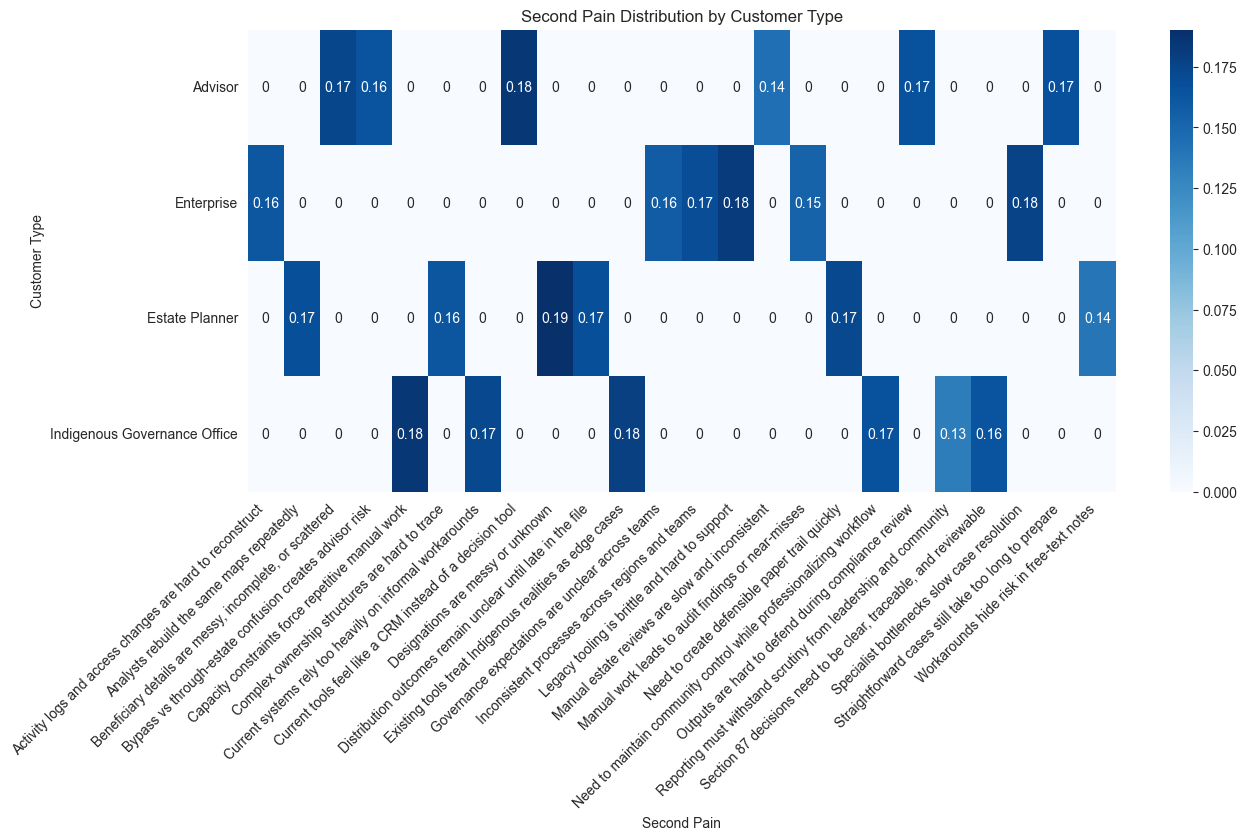

In [24]:
plt.figure(figsize=(14,6))

sns.heatmap(
    secondpain,
    annot=True,
    cmap='Blues'
)

plt.title('Second Pain Distribution by Customer Type')

plt.xlabel('Second Pain')
plt.ylabel('Customer Type')
plt.xticks(rotation=45, ha='right')
plt.show()

In [3]:
features = [
    'section87_relevance',
    'bypass_vs_through_estate_confusion',
    'needs_versioning_appendix',
    'needs_role_based_permissions',
    'wants_meeting_ready_answer_screen',
    'faster_than_excel_is_required',
    'auditability_is_top_priority',
    'export_quality_is_priority'
]

df[features].mean().sort_values(ascending=False)

auditability_is_top_priority          0.902244
export_quality_is_priority            0.831731
needs_versioning_appendix             0.571314
bypass_vs_through_estate_confusion    0.463942
wants_meeting_ready_answer_screen     0.461538
faster_than_excel_is_required         0.459936
needs_role_based_permissions          0.455128
section87_relevance                   0.254808
dtype: float64

In [9]:
fast = pd.crosstab(
    df['customer_type'],
    df['faster_than_excel_is_required'],
    normalize='index'
)
print(fast)

faster_than_excel_is_required     False     True 
customer_type                                    
Advisor                        0.235849  0.764151
Enterprise                     0.832727  0.167273
Estate Planner                 0.533333  0.466667
Indigenous Governance Office   0.742972  0.257028


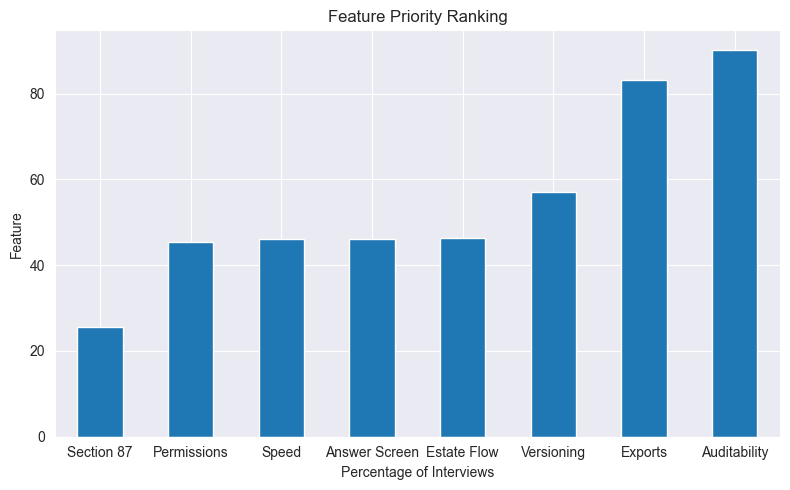

In [25]:
feature_labels = {
    'auditability_is_top_priority': 'Auditability',
    'export_quality_is_priority': 'Exports',
    'needs_versioning_appendix': 'Versioning',
    'bypass_vs_through_estate_confusion': 'Estate Flow',
    'wants_meeting_ready_answer_screen': 'Answer Screen',
    'faster_than_excel_is_required': 'Speed',
    'needs_role_based_permissions': 'Permissions',
    'section87_relevance': 'Section 87'
}
feature_pct = (
    df[list(feature_labels.keys())]
    .mean()
    .rename(index=feature_labels)
    .sort_values(ascending=True)
    * 100
)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

feature_pct.plot(kind='bar')

plt.xlabel('Percentage of Interviews')
plt.ylabel('Feature')
plt.title('Feature Priority Ranking')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('Feature_Priority.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
df.groupby("customer_type")["adoption_score_100"].mean().sort_values(ascending=False)

customer_type
Advisor                         74.206604
Indigenous Governance Office    74.085542
Estate Planner                  69.777000
Enterprise                      64.037818
Name: adoption_score_100, dtype: float64

In [35]:
pain_list = df.groupby("primary_pain_point")["primary_pain_point"].nunique()
print(pain_list)

primary_pain_point
Activity logs and access changes are hard to reconstruct               1
Analysts rebuild the same maps repeatedly                              1
Beneficiary details are messy, incomplete, or scattered                1
Bypass vs through-estate confusion creates advisor risk                1
Capacity constraints force repetitive manual work                      1
Complex ownership structures are hard to trace                         1
Current systems rely too heavily on informal workarounds               1
Current tools feel like a CRM instead of a decision tool               1
Designations are messy or unknown                                      1
Distribution outcomes remain unclear until late in the file            1
Existing tools treat Indigenous realities as edge cases                1
Governance expectations are unclear across teams                       1
Inconsistent processes across regions and teams                        1
Legacy tooling is brittle and ha

In [23]:
pain_percentage = df.groupby("primary_pain_point").size().reset_index( name='count')
pain_percentage['percentage'] = (pain_percentage["count"] / len(df))*100.0
print(pain_percentage)


                                   primary_pain_point  count  percentage
0   Activity logs and access changes are hard to r...     46    3.685897
1           Analysts rebuild the same maps repeatedly     51    4.086538
2   Beneficiary details are messy, incomplete, or ...     68    5.448718
3   Bypass vs through-estate confusion creates adv...     74    5.929487
4   Capacity constraints force repetitive manual work     28    2.243590
5      Complex ownership structures are hard to trace     49    3.926282
6   Current systems rely too heavily on informal w...     41    3.285256
7   Current tools feel like a CRM instead of a dec...     68    5.448718
8                   Designations are messy or unknown     44    3.525641
9   Distribution outcomes remain unclear until lat...     49    3.926282
10  Existing tools treat Indigenous realities as e...     43    3.445513
11   Governance expectations are unclear across teams     47    3.766026
12    Inconsistent processes across regions and tea

In [5]:
pain_score = df.groupby('primary_pain_point')["adoption_score_100"].agg(['mean','median']).reset_index()
print(pain_score.sort_values(by=['mean'], ascending=False))



                                   primary_pain_point       mean  median
17  Need to maintain community control while profe...  76.884211   77.90
18  Outputs are hard to defend during compliance r...  76.618310   76.80
4   Capacity constraints force repetitive manual work  76.203571   78.80
3   Bypass vs through-estate confusion creates adv...  75.017568   74.55
14    Manual estate reviews are slow and inconsistent  74.652000   76.10
20  Section 87 decisions need to be clear, traceab...  74.042857   74.80
19  Reporting must withstand scrutiny from leaders...  73.515789   73.00
2   Beneficiary details are messy, incomplete, or ...  73.500000   75.65
10  Existing tools treat Indigenous realities as e...  73.295349   74.20
22  Straightforward cases still take too long to p...  73.076471   74.20
7   Current tools feel like a CRM instead of a dec...  72.151471   72.10
6   Current systems rely too heavily on informal w...  71.709756   73.30
9   Distribution outcomes remain unclear until lat.

In [12]:
adoption_likli = df.groupby('adoption_likelihood')['adoption_score_100'].agg(['min','max'])
print(adoption_likli)

                      min   max
adoption_likelihood            
Likely               65.0  79.9
Possible             45.5  64.9
Unlikely             25.2  44.9
Very likely          80.0  98.0


In [6]:
# 1. Define the mapping dictionary (Matches your text exactly)
category_mapping = {
   #  (Process Efficiency & Bottlenecks)
    "Analysts rebuild the same maps repeatedly": "Process Efficiency & Bottlenecks",
    "Capacity constraints force repetitive manual work": "Process Efficiency & Bottlenecks",
    "Manual estate reviews are slow and inconsistent": "Process Efficiency & Bottlenecks",
    "Specialist bottlenecks slow case resolution": "Process Efficiency & Bottlenecks",
    "Straightforward cases still take too long to prepare": "Process Efficiency & Bottlenecks",

    # (Data Quality & Structure)
    "Beneficiary details are messy, incomplete, or scattered": "Data Quality & Structure",
    "Complex ownership structures are hard to trace": "Data Quality & Structure",
    "Designations are messy or unknown": "Data Quality & Structure",
    "Distribution outcomes remain unclear until late in the file": "Data Quality & Structure",

    #  (Compliance, Audit & Risk)
    "Bypass vs through-estate confusion creates advisor risk": "Compliance, Audit & Risk",
    "Manual work leads to audit findings or near-misses": "Compliance, Audit & Risk",
    "Need to create defensible paper trail quickly": "Compliance, Audit & Risk",
    "Outputs are hard to defend during compliance review": "Compliance, Audit & Risk",

    #  (Platform, Tools & Systems)
    "Activity logs and access changes are hard to reconstruct": "Platform, Tools & Systems",
    "Current systems rely too heavily on informal workarounds": "Platform, Tools & Systems",
    "Current tools feel like a CRM instead of a decision tool": "Platform, Tools & Systems",
    "Inconsistent processes across regions and teams": "Platform, Tools & Systems",
    "Legacy tooling is brittle and hard to support": "Platform, Tools & Systems",
    "Workarounds hide risk in free-text notes": "Platform, Tools & Systems",

    #  (Indigenous Realities & Governance)
    "Existing tools treat Indigenous realities as edge cases": "Indigenous Realities & Governance",
    "Governance expectations are unclear across teams": "Indigenous Realities & Governance",
    "Need to maintain community control while professionalizing workflow": "Indigenous Realities & Governance",
    "Reporting must withstand scrutiny from leadership and community": "Indigenous Realities & Governance",
    "Section 87 decisions need to be clear, traceable, and reviewable": "Indigenous Realities & Governance"
}


pain_score['business_pillar'] = pain_score['primary_pain_point'].map(category_mapping).fillna('Other Operations')

print(pain_score)


                                   primary_pain_point       mean  median  \
0   Activity logs and access changes are hard to r...  65.219565   62.90   
1           Analysts rebuild the same maps repeatedly  70.601961   70.40   
2   Beneficiary details are messy, incomplete, or ...  73.500000   75.65   
3   Bypass vs through-estate confusion creates adv...  75.017568   74.55   
4   Capacity constraints force repetitive manual work  76.203571   78.80   
5      Complex ownership structures are hard to trace  70.683673   70.80   
6   Current systems rely too heavily on informal w...  71.709756   73.30   
7   Current tools feel like a CRM instead of a dec...  72.151471   72.10   
8                   Designations are messy or unknown  68.268182   69.05   
9   Distribution outcomes remain unclear until lat...  70.751020   68.40   
10  Existing tools treat Indigenous realities as e...  73.295349   74.20   
11   Governance expectations are unclear across teams  63.963830   63.40   
12    Incons

In [9]:
tools_adoptions = pain_score.groupby("business_pillar")['mean'].mean().reset_index()

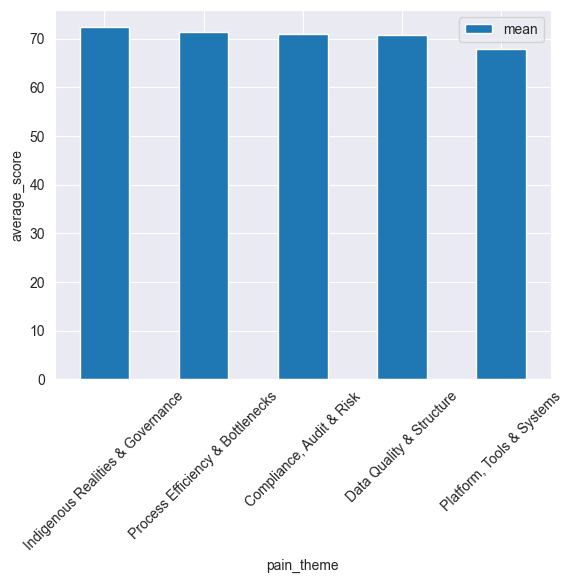

In [15]:
import matplotlib.pyplot as plt
tools_adoptions_sorted = tools_adoptions.sort_values(by="mean", ascending=False , inplace = True)
tools_adoptions.plot(kind='bar',
                     x = "business_pillar",
                     y = "mean", )
plt.xlabel("pain_theme")
plt.ylabel("average_score")
plt.xticks(rotation=45)
plt.savefig('pain_score.png', dpi=300, bbox_inches='tight')
plt.show()

In [37]:
buying_adoption = df[["buying_triggers","adoption_score_100"]].copy()
buying_adoption['buying_triggers'] = buying_adoption['buying_triggers'].str.split(';')
buying_adoption = buying_adoption.explode('buying_triggers')
buying_adoption['buying_triggers'] = buying_adoption['buying_triggers'].str.strip()

In [43]:

analysis_df = buying_adoption.groupby('buying_triggers')['adoption_score_100'].agg(['mean', 'count']).reset_index()

analysis_df.columns = ['buying_triggers','Average Adoption Score', 'Sample Count']

analysis_df.dtypes

buying_triggers            object
Average Adoption Score    float64
Sample Count                int64
dtype: object

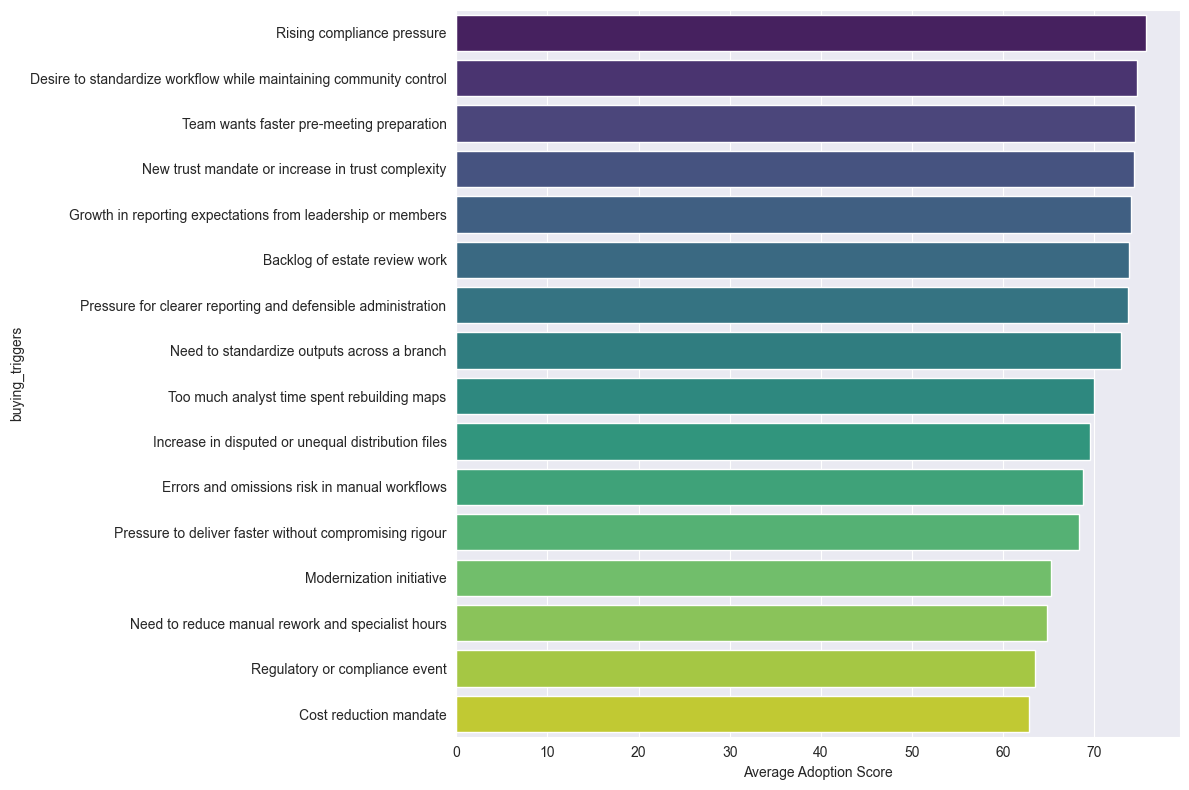

In [49]:
analysis_df = analysis_df.sort_values(by='Average Adoption Score', ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x="Average Adoption Score", y="buying_triggers", data=analysis_df, palette="viridis",
hue="buying_triggers",
    legend=False            )

plt.xlabel("Average Adoption Score")
plt.ylabel("buying_triggers")
plt.tight_layout()
plt.savefig('triggers_score.png', dpi=300, bbox_inches='tight')
plt.show()